# Energy Expenditure Estimation from Wearable Biosignals
### Multi-Modal Deep Learning with Signal Fusion

**Dataset:** 10 subjects × 18–22 activity trials, 1Hz pre-processed biosignals.
**Task:** Regression — predict Energy Expenditure (W/kg) from 16 wearable sensor signals.
**Evaluation:** Leave-One-Subject-Out (LOSO) cross-validation.

**Pipeline:**
1. Imports & Setup
2. Data Loading & Exploration
3. Signal Groups
4. Windowed LOSO Dataset
5. 1D-CNN Architecture
6. HPO on Heart Rate (Optuna)
7. Phase 1 — Single-Signal Baselines (16 signals)
8. Phase 2 — Fusion Models (Early / Intermediate / Late)
9. Regularization Analysis
10. Results & Visualizations


## 1. Imports & Setup

In [1]:
import os, sys, random, logging, warnings
from pathlib import Path
from itertools import product
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.INFO, format="[%(asctime)s] %(message)s",
                    handlers=[logging.StreamHandler(sys.stdout)])
logger = logging.getLogger(__name__)

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    torch.backends.cudnn.benchmark = True


Device: cuda
GPU: Tesla T4


## 2. Data Loading & Exploration

**Data structure (confirmed from inspection):**
- 1Hz time-series of pre-extracted biosignal features — not raw sensor data.
- ~360 rows per activity (6 minutes), 18 activities per subject, 10 subjects.
- EE (W/kg) is **constant within each activity** — this is activity-level regression,
  with the temporal signal variation providing the context the model uses to predict it.
- 16 input signals (VO₂ excluded — it is the direct basis of the EE ground truth label
  and must not be used as an input).
- No missing values.

In [2]:
DATA_DIR = Path("/kaggle/input/datasets/lemuelmensah/energy-expenditure-data") 

def load_all_subjects(data_dir: Path) -> Dict[int, pd.DataFrame]:
    import glob, re

    all_csvs = sorted(glob.glob(str(data_dir / "*.csv")))
    if not all_csvs:
        raise FileNotFoundError(f"No CSV files found in {data_dir}.")

    candidates = []
    for f in all_csvs:
        stem = Path(f).stem
        if "subject" in stem.lower():
            m = re.search(r"(\d+)", stem)
            if m:
                candidates.append((int(m.group(1)), f))

    if not candidates:
        for i, f in enumerate(all_csvs, start=1):
            m = re.search(r"(\d+)", Path(f).stem)
            sid = int(m.group(1)) if m else i
            candidates.append((sid, f))

    if not candidates:
        raise FileNotFoundError(
            f"Could not identify subject CSV files in {data_dir}.\n"
            f"Files found: {[Path(f).name for f in all_csvs]}"
        )

    candidates.sort(key=lambda x: x[0])

    subjects = {}
    for sid, f in candidates:
        df = pd.read_csv(f)
        df.columns = df.columns.str.strip()   # strip whitespace from column names
        subjects[sid] = df
        print(f"Subject {sid:2d} ({Path(f).name}): {len(df):5d} rows | "
                    f"{df['Activity Code'].nunique()} activities | "
                    f"EE range [{df['Energy expenditures (W/kg)'].min():.2f}, "
                    f"{df['Energy expenditures (W/kg)'].max():.2f}] W/kg")
    print(f"Loaded {len(subjects)} subjects")
    return subjects

subjects = load_all_subjects(DATA_DIR)
n_subjects = len(subjects)

Subject  1 (Subject (1).csv):  6488 rows | 18 activities | EE range [0.97, 9.98] W/kg
Subject  2 (Subject (2).csv):  7536 rows | 21 activities | EE range [1.52, 14.00] W/kg
Subject  3 (Subject (3).csv):  7200 rows | 20 activities | EE range [2.00, 13.18] W/kg
Subject  4 (Subject (4).csv):  7201 rows | 20 activities | EE range [1.29, 11.03] W/kg
Subject  5 (Subject (5).csv):  7548 rows | 21 activities | EE range [1.93, 13.85] W/kg
Subject  6 (Subject (6).csv):  7200 rows | 20 activities | EE range [1.31, 12.27] W/kg
Subject  7 (Subject (7).csv):  7200 rows | 20 activities | EE range [1.78, 15.18] W/kg
Subject  8 (Subject (8).csv):  7200 rows | 20 activities | EE range [1.68, 11.00] W/kg
Subject  9 (Subject (9).csv):  7200 rows | 20 activities | EE range [1.72, 13.57] W/kg
Subject 10 (Subject (10).csv):  6475 rows | 18 activities | EE range [1.47, 9.64] W/kg
Loaded 10 subjects


In [3]:
TARGET_COL   = "Energy expenditures (W/kg)"
TIME_COL     = "Time (s)"
ACTIVITY_COL = "Activity Code"
VO2_COL      = "VO2"

ALL_SIGNALS = [
    "Waist Acceleration",
    "Chest Acceleration",
    "Left Ankle Acceleration",
    "right Ankle Acceleration",
    "EMG_magnitude_left",
    "EMG_magnitude_right",
    "left wrist Acceleration",
    "right wrist Acceleration",
    "left wrist electrodermal",
    "right wrist electrodermal",
    "left wrist Temperature",
    "right wrist Temperature",
    "Breath Frequency",
    "Minute Ventilation",
    "SpO2",
    "Heart Rate",
]
N_SIGNALS = len(ALL_SIGNALS)
print(f"{N_SIGNALS} input signals (VO2 excluded)")

SIGNAL_NAMES = {
    "Waist Acceleration":        "Waist Acc",
    "Chest Acceleration":        "Chest Acc",
    "Left Ankle Acceleration":   "L Ankle Acc",
    "right Ankle Acceleration":  "R Ankle Acc",
    "EMG_magnitude_left":        "EMG Left",
    "EMG_magnitude_right":       "EMG Right",
    "left wrist Acceleration":   "L Wrist Acc",
    "right wrist Acceleration":  "R Wrist Acc",
    "left wrist electrodermal":  "L EDA",
    "right wrist electrodermal": "R EDA",
    "left wrist Temperature":    "L Temp",
    "right wrist Temperature":   "R Temp",
    "Breath Frequency":          "Breath Freq",
    "Minute Ventilation":        "Min Vent",
    "SpO2":                      "SpO2",
    "Heart Rate":                "Heart Rate",
}

16 input signals (VO2 excluded)


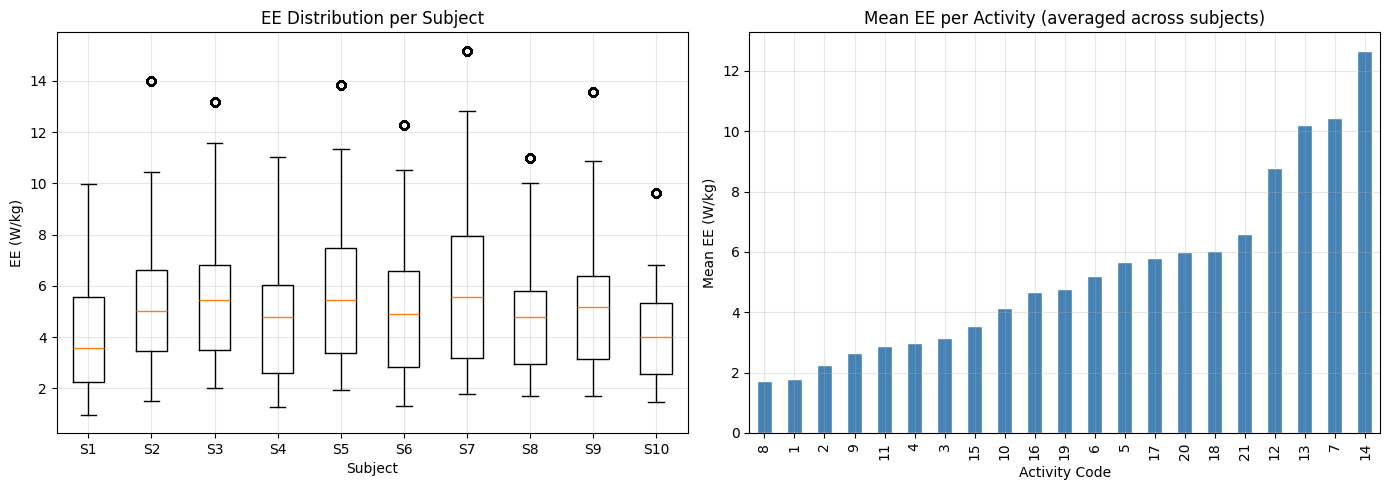

EE range across all subjects: [0.970, 15.178] W/kg
Total rows: 71,248


In [4]:
all_dfs = pd.concat([df.assign(subject=sid) for sid,df in subjects.items()], ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ee_by_subject = [subjects[s][TARGET_COL].values for s in sorted(subjects)]
axes[0].boxplot(ee_by_subject, labels=[f"S{s}" for s in sorted(subjects)])
axes[0].set_xlabel("Subject"); axes[0].set_ylabel("EE (W/kg)")
axes[0].set_title("EE Distribution per Subject"); axes[0].grid(True, alpha=0.3)

act_ee = all_dfs.groupby(ACTIVITY_COL)[TARGET_COL].mean().sort_values()
act_ee.plot(kind="bar", ax=axes[1], color="steelblue", edgecolor="white")
axes[1].set_xlabel("Activity Code"); axes[1].set_ylabel("Mean EE (W/kg)")
axes[1].set_title("Mean EE per Activity (averaged across subjects)"); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print(f"EE range across all subjects: [{all_dfs[TARGET_COL].min():.3f}, {all_dfs[TARGET_COL].max():.3f}] W/kg")
print(f"Total rows: {len(all_dfs):,}")

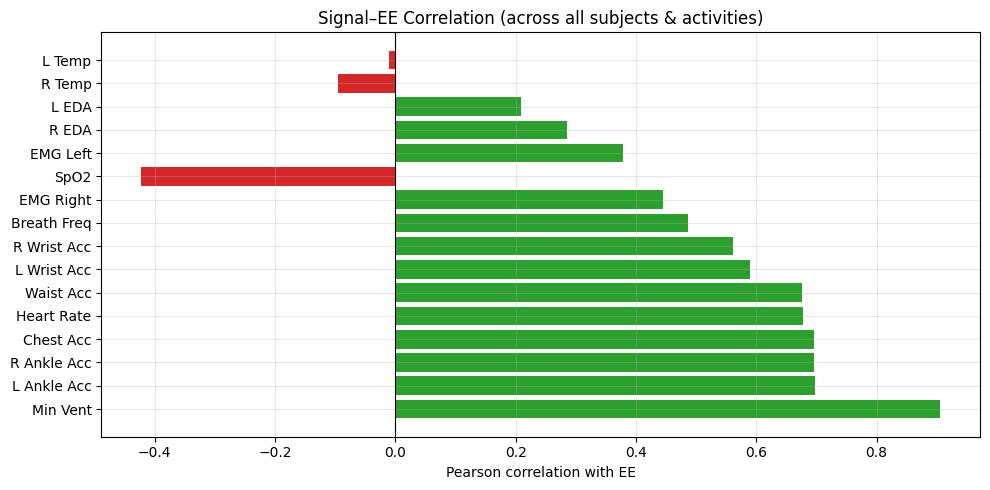

Top 5 positively correlated: Minute Ventilation          0.905608
Left Ankle Acceleration     0.697810
right Ankle Acceleration    0.696678
Chest Acceleration          0.695277
Heart Rate                  0.677658
Top 5 negatively correlated: EMG_magnitude_left           0.377908
right wrist electrodermal    0.285375
left wrist electrodermal     0.208620
right wrist Temperature     -0.094742
left wrist Temperature      -0.011062


In [5]:
corr = all_dfs[ALL_SIGNALS + [TARGET_COL]].corr()[TARGET_COL].drop(TARGET_COL).sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#2ca02c" if v>0 else "#d62728" for v in corr.values]
ax.barh([SIGNAL_NAMES[s] for s in corr.index], corr.values, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Pearson correlation with EE")
ax.set_title("Signal–EE Correlation (across all subjects & activities)")
ax.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

print("Top 5 positively correlated:", corr.head(5).to_string())
print("Top 5 negatively correlated:", corr.tail(5).to_string())

## 3. Signal Groups

In [6]:
SIGNAL_GROUPS = {
    "G1_Local": [
        "Waist Acceleration", "Chest Acceleration",
        "Left Ankle Acceleration", "right Ankle Acceleration",
        "left wrist Acceleration", "right wrist Acceleration",
        "EMG_magnitude_left", "EMG_magnitude_right",
    ],
    "G2_Global": [
        "left wrist electrodermal", "right wrist electrodermal",
        "left wrist Temperature", "right wrist Temperature",
        "Breath Frequency", "Minute Ventilation",
        "Heart Rate", "SpO2",
    ],
    "G3_Hexoskin": [
        "Waist Acceleration",   # hip = waist sensor in this dataset
        "Breath Frequency", "Minute Ventilation", "Heart Rate",
    ],
    "G4_Physiological": [
        "Breath Frequency", "Minute Ventilation", "Heart Rate", "SpO2",
    ],
    "G5_Motion": [
        "Waist Acceleration", "Chest Acceleration",
        "Left Ankle Acceleration", "right Ankle Acceleration",
        "left wrist Acceleration", "right wrist Acceleration",
    ],
    "G6_All": ALL_SIGNALS,
}

for gname, gsigs in SIGNAL_GROUPS.items():
    print(f"{gname:20s}: {len(gsigs)} signals -- {[SIGNAL_NAMES[s] for s in gsigs]}")

G1_Local            : 8 signals -- ['Waist Acc', 'Chest Acc', 'L Ankle Acc', 'R Ankle Acc', 'L Wrist Acc', 'R Wrist Acc', 'EMG Left', 'EMG Right']
G2_Global           : 8 signals -- ['L EDA', 'R EDA', 'L Temp', 'R Temp', 'Breath Freq', 'Min Vent', 'Heart Rate', 'SpO2']
G3_Hexoskin         : 4 signals -- ['Waist Acc', 'Breath Freq', 'Min Vent', 'Heart Rate']
G4_Physiological    : 4 signals -- ['Breath Freq', 'Min Vent', 'Heart Rate', 'SpO2']
G5_Motion           : 6 signals -- ['Waist Acc', 'Chest Acc', 'L Ankle Acc', 'R Ankle Acc', 'L Wrist Acc', 'R Wrist Acc']
G6_All              : 16 signals -- ['Waist Acc', 'Chest Acc', 'L Ankle Acc', 'R Ankle Acc', 'EMG Left', 'EMG Right', 'L Wrist Acc', 'R Wrist Acc', 'L EDA', 'R EDA', 'L Temp', 'R Temp', 'Breath Freq', 'Min Vent', 'SpO2', 'Heart Rate']


## 4. Windowed LOSO Dataset

**Windowing strategy:**
- Sliding window of `WINDOW_SIZE` seconds (1 step = 1 second at 1Hz).
- Windows must NOT cross activity boundaries (each window belongs to exactly one activity).
- Each window is labelled with the (constant) EE value of its activity.
- At evaluation time, predictions are aggregated per activity (mean) before computing
  RMSE/MAE/R² -- this gives activity-level performance matching the label granularity.

**Normalization:**
- Per-signal StandardScaler **fit on training subjects only**, applied to validation and test subjects.
- Fitted inside each LOSO fold to prevent leakage.

**Internal validation split (for early stopping):**
- One subject is held out from the 9 training subjects as a validation subject (`val_sid`),
  separate from the LOSO test subject.
- This is a **subject-level** split, not a random window-level split: training windows overlap
  heavily (`stride_train=5` over a `window_size=30` window), so a random split would place
  near-duplicate, overlapping windows in both train and val and make early stopping overly
  optimistic. Holding out a whole subject avoids that leakage.

**Data augmentation (training split only):**
- Additive Gaussian jitter and random amplitude scaling, applied only to training windows.
- Validation and test windows are never augmented.
- Augmentation strength (`jitter_std`, `scale_min`/`scale_max`, `aug_p`) is tuned once during
  HPO (Section 6) on the Heart Rate proxy signal, then locked for every experiment -- same
  policy as the other hyperparameters.


In [7]:
def create_windows(df: pd.DataFrame, signals: List[str],
                   window_size: int = 30, stride: int = 1) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    Xs, ys, acts = [], [], []
    n_dropped_nan = 0
    for act_code in df[ACTIVITY_COL].unique():
        seg = df[df[ACTIVITY_COL] == act_code].sort_values(TIME_COL)
        sig_vals = seg[signals].values.astype(np.float32)  # (T, n_signals)
        ee_val   = seg[TARGET_COL].iloc[0]                 # constant within activity

        n = len(sig_vals)
        if n < window_size:
            continue   # skip activities shorter than window (shouldn't happen in this dataset)

        for start in range(0, n - window_size + 1, stride):
            window = sig_vals[start:start + window_size]
            if np.isnan(window).any():
                # Some signals (e.g. EMG) have missing values for certain subjects/activities.
                # Drop the window rather than let NaNs propagate into scaling/training.
                n_dropped_nan += 1
                continue
            Xs.append(window)
            ys.append(ee_val)
            acts.append(act_code)

    if n_dropped_nan > 0:
        logger.warning(f"create_windows: dropped {n_dropped_nan} window(s) containing NaN "
                        f"for signals {signals}")

    if len(Xs) == 0:
        raise ValueError(f"No valid (NaN-free) windows produced for signals {signals}. "
                          f"Check the raw data for this signal/subject.")

    return (np.stack(Xs, axis=0),
            np.array(ys, dtype=np.float32),
            np.array(acts, dtype=np.int32))

class LOSODataset(Dataset):
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.from_numpy(X)   # (n, window_size, n_signals)
        self.y = torch.from_numpy(y).unsqueeze(1)  # (n, 1)

    def __len__(self): return len(self.y)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

class AugmentedLOSODataset(Dataset):
    def __init__(self, X: np.ndarray, y: np.ndarray,
                 jitter_std: float = 0.03, scale_range: Tuple[float, float] = (0.9, 1.1),
                 p: float = 0.5):
        self.X = torch.from_numpy(X)
        self.y = torch.from_numpy(y).unsqueeze(1)
        self.jitter_std = jitter_std
        self.scale_range = scale_range
        self.p = p

    def __len__(self): return len(self.y)

    def __getitem__(self, idx):
        x = self.X[idx].clone()
        if self.jitter_std > 0 and torch.rand(1).item() < self.p:
            x = x + torch.randn_like(x) * self.jitter_std
        if torch.rand(1).item() < self.p:
            x = x * torch.empty(1).uniform_(*self.scale_range)
        return x, self.y[idx]

def build_loso_fold(subjects: Dict, test_sid: int, signals: List[str],
                    window_size: int = 30, stride_train: int = 5,
                    stride_test: int = 1, val_sid: Optional[int] = None,
                    jitter_std: float = 0.03, scale_range: Tuple[float, float] = (0.9, 1.1),
                    aug_p: float = 0.5) -> Tuple:
    train_sids = [s for s in subjects if s != test_sid]
    if val_sid is None:
        val_sid = train_sids[0]
    fit_sids = [s for s in train_sids if s != val_sid]

    fit_X_raw, fit_y = [], []
    for sid in fit_sids:
        X_, y_, _ = create_windows(subjects[sid], signals, window_size, stride_train)
        fit_X_raw.append(X_); fit_y.append(y_)
    fit_X_raw = np.concatenate(fit_X_raw)  # (N_fit, W, n_sig)
    fit_y     = np.concatenate(fit_y)
    
    scaler = StandardScaler()
    n_fit, W, n_sig = fit_X_raw.shape
    scaler.fit(fit_X_raw.reshape(-1, n_sig))  
    if np.any(scaler.scale_ < 1e-8):
        flat_signals = signals if isinstance(signals, list) else [signals]
        bad = [flat_signals[i] for i, s in enumerate(scaler.scale_) if s < 1e-8]
        logger.warning(f"build_loso_fold: near-zero variance detected for {bad} "
                        f"(test_sid={test_sid}) -- clamping scale to avoid div-by-zero")
        scaler.scale_ = np.where(scaler.scale_ < 1e-8, 1.0, scaler.scale_)

    train_X = scaler.transform(fit_X_raw.reshape(-1, n_sig)).reshape(n_fit, W, n_sig).astype(np.float32)

    # ---- Validation windows from val_sid (dense stride, no augmentation) ----
    val_X_raw, val_y, _ = create_windows(subjects[val_sid], signals, window_size, stride_test)
    n_val = len(val_y)
    val_X = scaler.transform(val_X_raw.reshape(-1, n_sig)).reshape(n_val, W, n_sig).astype(np.float32)

    # ---- Test windows from test_sid (dense stride, for activity-level aggregation) ----
    test_X_raw, test_y, test_acts = create_windows(subjects[test_sid], signals, window_size, stride_test)
    n_test = len(test_y)
    test_X  = scaler.transform(test_X_raw.reshape(-1, n_sig)).reshape(n_test, W, n_sig).astype(np.float32)

    train_ds = AugmentedLOSODataset(train_X, fit_y,
                                     jitter_std=jitter_std, scale_range=scale_range, p=aug_p)
    val_ds   = LOSODataset(val_X, val_y)

    return train_ds, val_ds, test_X, test_y, test_acts, scaler


def activity_level_metrics(y_true_windows: np.ndarray,
                            y_pred_windows: np.ndarray,
                            act_ids: np.ndarray) -> Dict[str, float]:
    act_true, act_pred = [], []
    for act in np.unique(act_ids):
        mask = act_ids == act
        act_true.append(y_true_windows[mask][0])     # EE is constant within activity
        act_pred.append(y_pred_windows[mask].mean())  # average window predictions
    act_true = np.array(act_true); act_pred = np.array(act_pred)
    rmse = np.sqrt(mean_squared_error(act_true, act_pred))
    mae  = mean_absolute_error(act_true, act_pred)
    r2   = r2_score(act_true, act_pred)
    return {"rmse": rmse, "mae": mae, "r2": r2,
            "y_true": act_true, "y_pred": act_pred}

_X, _y, _acts = create_windows(subjects[1], ALL_SIGNALS, window_size=30, stride=1)
print(f"Subject 1 | windows: {len(_X):,} | X shape: {_X.shape} | y range: [{_y.min():.3f}, {_y.max():.3f}]")
print(f"Activity codes present: {np.unique(_acts).tolist()}")

Subject 1 | windows: 5,966 | X shape: (5966, 30, 16) | y range: [0.970, 9.976]
Activity codes present: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18]


## 5. 1D-CNN Architecture

**Why 1D-CNN?** The data is 1Hz pre-extracted features (not raw sensor data), so each
window is a short (~30-step) multivariate time-series. 1D-CNN captures local temporal
patterns efficiently and trains fast. A CNN-GRU hybrid is implemented as an alternative backbone.

All architectures share the same hyperparameters throughout all experiments (single-signal
and fusion) so performance differences are attributable to fusion strategy, not
architectural differences.

**Regularization:** three techniques are used together that are
dropout (inside the encoder and head), early stopping (against a subject-level validation
split, and training-time data augmentation (jitter + amplitude scaling. All three are tuned once on the Heart Rate proxy signal and then locked for every experiment.

**Note on embedding width:** `SingleSignalModel` uses `embed_dim=64`, while the per-signal
encoders inside `IntermediateFusionModel` / `LateFusionModel` use `embed_dim=32`. This is a
deliberate choice to keep the concatenated feature width manageable for groups of up to 16
signals (32*16=512 vs. 64*16=1024) the encoder's conv layers (n_filters, kernel_size,
n_layers, dropout) are otherwise identical and use the same locked hyperparameters. This is
called out here explicitly since it is a minor deviation from strict architecture
consistency across single-signal and fusion experiments.

**Fusion strategies:**
- **Early:** concatenate signals along feature dimension before the network.
- **Intermediate:** separate CNN encoder per signal -> concatenate embeddings -> shared head.
- **Late:** separate complete sub-network per signal -> learned combination of predictions.

In [8]:
HP = {
    "window_size":    30,     
    "stride_train":   5,
    "n_filters":      64,
    "kernel_size":    5,
    "n_layers":       3,
    "dropout":        0.3,
    "lr":             1e-3,
    "weight_decay":   1e-4,
    "batch_size":     128,
    "jitter_std":     0.03,   
    "scale_min":      0.9,    
    "scale_max":      1.1,    
    "aug_p":          0.5,  
    "max_epochs":     100,
    "patience":       10,
}

class CNN1DEncoder(nn.Module):
    def __init__(self, in_channels: int, n_filters: int = 64,
                 kernel_size: int = 5, n_layers: int = 3,
                 dropout: float = 0.3, embed_dim: int = 64):
        super().__init__()
        layers = []
        ch_in  = in_channels
        for i in range(n_layers):
            ch_out = n_filters * (2 ** min(i, 2))   # 64, 128, 128 for 3 layers
            layers += [
                nn.Conv1d(ch_in, ch_out, kernel_size=kernel_size, padding=kernel_size//2),
                nn.BatchNorm1d(ch_out),
                nn.ReLU(inplace=True),
                nn.Dropout(p=dropout),
            ]
            if i < n_layers - 1:
                layers.append(nn.MaxPool1d(kernel_size=2, stride=2))
            ch_in = ch_out

        self.conv_layers = nn.Sequential(*layers)
        self.pool        = nn.AdaptiveAvgPool1d(4)
        self.fc          = nn.Linear(ch_in * 4, embed_dim)

    def forward(self, x):
        # x: (batch, in_channels, window_size)
        x = self.conv_layers(x)
        x = self.pool(x)
        x = x.flatten(1)
        return F.relu(self.fc(x))

class RegressionHead(nn.Module):
    def __init__(self, embed_dim: int = 64, dropout: float = 0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(embed_dim, 32), nn.ReLU(inplace=True),
            nn.Dropout(p=dropout),
            nn.Linear(32, 1),
        )
    def forward(self, x): return self.net(x)

class SingleSignalModel(nn.Module):
    def __init__(self, hp: dict):
        super().__init__()
        self.encoder = CNN1DEncoder(
            in_channels=1,
            n_filters=hp["n_filters"], kernel_size=hp["kernel_size"],
            n_layers=hp["n_layers"], dropout=hp["dropout"],
        )
        self.head = RegressionHead(embed_dim=64, dropout=hp["dropout"])

    def forward(self, x):
        x = x.permute(0, 2, 1)   
        return self.head(self.encoder(x))

class EarlyFusionModel(nn.Module):
    def __init__(self, n_signals: int, hp: dict):
        super().__init__()
        self.encoder = CNN1DEncoder(
            in_channels=n_signals,
            n_filters=hp["n_filters"], kernel_size=hp["kernel_size"],
            n_layers=hp["n_layers"], dropout=hp["dropout"],
        )
        self.head = RegressionHead(embed_dim=64, dropout=hp["dropout"])

    def forward(self, x):
        # x: (batch, window_size, n_signals)
        x = x.permute(0, 2, 1)   # -> (batch, n_signals, window_size)
        return self.head(self.encoder(x))

class IntermediateFusionModel(nn.Module):
    def __init__(self, n_signals: int, hp: dict):
        super().__init__()
        self.encoders = nn.ModuleList([
            CNN1DEncoder(in_channels=1, n_filters=hp["n_filters"],
                         kernel_size=hp["kernel_size"], n_layers=hp["n_layers"],
                         dropout=hp["dropout"], embed_dim=32)
            for _ in range(n_signals)
        ])
        self.head = RegressionHead(embed_dim=32 * n_signals, dropout=hp["dropout"])

    def forward(self, x):
        embeds = []
        for i, enc in enumerate(self.encoders):
            xi = x[:, :, i:i+1].permute(0, 2, 1)   
            embeds.append(enc(xi))
        fused = torch.cat(embeds, dim=1)             
        return self.head(fused)

class LateFusionModel(nn.Module):
    def __init__(self, n_signals: int, hp: dict):
        super().__init__()
        self.sub_nets = nn.ModuleList([
            nn.Sequential(
                CNN1DEncoder(in_channels=1, n_filters=hp["n_filters"],
                             kernel_size=hp["kernel_size"], n_layers=hp["n_layers"],
                             dropout=hp["dropout"], embed_dim=32),
                RegressionHead(embed_dim=32, dropout=hp["dropout"]),
            )
            for _ in range(n_signals)
        ])
        self.combiner = nn.Linear(n_signals, 1, bias=True)

    def forward(self, x):
        preds = []
        for i, net in enumerate(self.sub_nets):
            xi = x[:, :, i:i+1].permute(0, 2, 1)   
            preds.append(net(xi))
        stacked = torch.cat(preds, dim=1)            
        return self.combiner(stacked)                

_hp = {**HP, "n_filters":32, "n_layers":2}   
_dummy = torch.randn(8, HP["window_size"], 4)  
_m_early = EarlyFusionModel(4, _hp)
_m_inter = IntermediateFusionModel(4, _hp)
_m_late  = LateFusionModel(4, _hp)
assert _m_early(_dummy).shape == (8,1)
assert _m_inter(_dummy).shape == (8,1)
assert _m_late(_dummy).shape  == (8,1)
print("All model output shapes verified: (8, 1) OK")

All model output shapes verified: (8, 1) OK


## 6. HPO on Heart Rate (Optuna)

Heart Rate is used as the proxy signal for HPO, as it is a well-known EE predictor.
The winning configuration is locked for **all** subsequent experiments (single-signal
and fusion alike) -- re-tuning per signal or per group would confound the comparison.

HPO uses a **subject-level proxy split** instead of full LOSO (which would require 10x
training per trial and make the search prohibitively expensive): train on 8 subjects,
early-stop on 1 validation subject, and evaluate the proxy metric on subject S1 (held out
as the HPO "test" subject). Once hyperparameters are locked, full LOSO is used for all
reported results.

In [9]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def train_model(model, train_ds, val_ds, max_epochs, lr, weight_decay, batch_size, patience,
                device, verbose=False):
    tr_loader  = DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.MSELoss()
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

    import math, copy
    best_val, best_state, patience_cnt = float("inf"), None, 0
    history = {"train": [], "val": []}

    model.to(device)
    for epoch in range(1, max_epochs + 1):
        # train
        model.train()
        tr_loss = 0.0
        for X, y in tr_loader:
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(X), y)
            loss.backward(); optimizer.step()
            tr_loss += loss.item() * X.size(0)
        tr_loss /= len(train_ds)

        # validate
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X, y in val_loader:
                X, y = X.to(device), y.to(device)
                val_loss += criterion(model(X), y).item() * X.size(0)
        val_loss /= len(val_ds)

        if math.isnan(tr_loss) or math.isnan(val_loss) or math.isinf(tr_loss) or math.isinf(val_loss):
            raise RuntimeError(
                f"train_model: non-finite loss at epoch {epoch} "
                f"(train_loss={tr_loss}, val_loss={val_loss}). "
                f"This usually means NaN/inf values reached the model -- check the input "
                f"signals for NaNs or zero-variance columns, or lower the learning rate."
            )

        scheduler.step(val_loss)
        history["train"].append(tr_loss)
        history["val"].append(val_loss)

        if val_loss < best_val - 1e-5:
            best_val = val_loss
            best_state = copy.deepcopy(model.state_dict())
            patience_cnt = 0
        else:
            patience_cnt += 1
            if patience_cnt >= patience:
                if verbose: print(f"  Early stop at epoch {epoch}")
                break

    if best_state is None:
        logger.warning("train_model: best_state was never set; using last-epoch weights.")
        best_state = model.state_dict()
        best_val = history["val"][-1] if history["val"] else best_val

    model.load_state_dict(best_state)
    return best_val, history

def run_single_signal_loso(signal: str, hp: dict, subjects: dict,
                            verbose: bool = False) -> Dict:
    fold_metrics = []
    all_true, all_pred = [], []

    for test_sid in sorted(subjects.keys()):
        train_ds, val_ds, test_X, test_y, test_acts, _ = build_loso_fold(
            subjects, test_sid, [signal],
            window_size=hp["window_size"], stride_train=hp["stride_train"],
            jitter_std=hp["jitter_std"], scale_range=(hp["scale_min"], hp["scale_max"]),
            aug_p=hp["aug_p"],
        )
        model = SingleSignalModel(hp)
        train_model(model, train_ds, val_ds, hp["max_epochs"], hp["lr"], hp["weight_decay"],
                    hp["batch_size"], hp["patience"], DEVICE)

        model.eval()
        with torch.no_grad():
            X_t = torch.from_numpy(test_X).to(DEVICE)
            preds = model(X_t).cpu().numpy().flatten()

        m = activity_level_metrics(test_y, preds, test_acts)
        fold_metrics.append(m)
        all_true.extend(m["y_true"]); all_pred.extend(m["y_pred"])
        if verbose:
            print(f"  S{test_sid}: RMSE={m['rmse']:.3f}  MAE={m['mae']:.3f}  R²={m['r2']:.3f}")

    rmse_vals = [m["rmse"] for m in fold_metrics]
    mae_vals  = [m["mae"]  for m in fold_metrics]
    r2_vals   = [m["r2"]   for m in fold_metrics]
    return {
        "signal": signal,
        "rmse_mean": np.mean(rmse_vals), "rmse_std": np.std(rmse_vals),
        "mae_mean":  np.mean(mae_vals),  "mae_std":  np.std(mae_vals),
        "r2_mean":   np.mean(r2_vals),   "r2_std":   np.std(r2_vals),
        "y_true": np.array(all_true),    "y_pred": np.array(all_pred),
        "fold_metrics": fold_metrics,
    }

def hpo_objective(trial):
    hp_trial = {
        "window_size":   trial.suggest_categorical("window_size", [15, 30, 60]),
        "stride_train":  5,
        "n_filters":     trial.suggest_categorical("n_filters",   [32, 64, 128]),
        "kernel_size":   trial.suggest_categorical("kernel_size", [3, 5, 7]),
        "n_layers":      trial.suggest_categorical("n_layers",    [2, 3, 4]),
        "dropout":       trial.suggest_float("dropout",           0.1, 0.5, step=0.1),
        "lr":            trial.suggest_float("lr",                1e-4, 1e-2, log=True),
        "weight_decay":  trial.suggest_float("weight_decay",      1e-5, 1e-3, log=True),
        "batch_size":    trial.suggest_categorical("batch_size",  [64, 128, 256]),
        # ---- augmentation hyperparameters ----
        "jitter_std":    trial.suggest_float("jitter_std",        0.0, 0.08),
        "scale_min":     trial.suggest_float("scale_min",         0.85, 1.0),
        "scale_max":     trial.suggest_float("scale_max",         1.0, 1.15),
        "aug_p":         trial.suggest_float("aug_p",             0.0, 0.8),
        "max_epochs":    50,    # reduced for HPO speed
        "patience":      8,
    }
    train_ds, val_ds, test_X, test_y, test_acts, _ = build_loso_fold(
        subjects, test_sid=1, signals=["Heart Rate"],
        window_size=hp_trial["window_size"], stride_train=hp_trial["stride_train"],
        jitter_std=hp_trial["jitter_std"],
        scale_range=(hp_trial["scale_min"], hp_trial["scale_max"]),
        aug_p=hp_trial["aug_p"],
    )
    model = SingleSignalModel(hp_trial)
    train_model(model, train_ds, val_ds, hp_trial["max_epochs"], hp_trial["lr"],
                hp_trial["weight_decay"], hp_trial["batch_size"],
                hp_trial["patience"], DEVICE)
    model.eval()
    with torch.no_grad():
        preds = model(torch.from_numpy(test_X).to(DEVICE)).cpu().numpy().flatten()
    m = activity_level_metrics(test_y, preds, test_acts)
    return m["rmse"]   # minimize RMSE

HPO_N_TRIALS = 40  
study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(hpo_objective, n_trials=HPO_N_TRIALS)

print(f"HPO complete. Best RMSE: {study.best_value:.4f}")
print(f"Best params: {study.best_params}")

HP.update({
    "window_size":  study.best_params["window_size"],
    "n_filters":    study.best_params["n_filters"],
    "kernel_size":  study.best_params["kernel_size"],
    "n_layers":     study.best_params["n_layers"],
    "dropout":      study.best_params["dropout"],
    "lr":           study.best_params["lr"],
    "weight_decay": study.best_params["weight_decay"],
    "batch_size":   study.best_params["batch_size"],
    "jitter_std":   study.best_params["jitter_std"],
    "scale_min":    study.best_params["scale_min"],
    "scale_max":    study.best_params["scale_max"],
    "aug_p":        study.best_params["aug_p"],
    "max_epochs":   100,
    "patience":     10,
})
print("Locked HP:", HP)

HPO complete. Best RMSE: 0.9796
Best params: {'window_size': 15, 'n_filters': 64, 'kernel_size': 3, 'n_layers': 2, 'dropout': 0.1, 'lr': 0.0014370513133303753, 'weight_decay': 3.8709165475450005e-05, 'batch_size': 64, 'jitter_std': 0.03261943587194872, 'scale_min': 0.9898128084726875, 'scale_max': 1.135543146649906, 'aug_p': 0.0013179184953258506}
Locked HP: {'window_size': 15, 'stride_train': 5, 'n_filters': 64, 'kernel_size': 3, 'n_layers': 2, 'dropout': 0.1, 'lr': 0.0014370513133303753, 'weight_decay': 3.8709165475450005e-05, 'batch_size': 64, 'jitter_std': 0.03261943587194872, 'scale_min': 0.9898128084726875, 'scale_max': 1.135543146649906, 'aug_p': 0.0013179184953258506, 'max_epochs': 100, 'patience': 10}


## 7. Phase 1 — Single-Signal Baselines

In [10]:
if "single_signal_results" not in dir():
    single_signal_results = {}

for i, signal in enumerate(ALL_SIGNALS, 1):
    if signal in single_signal_results:
        print(f"[{i:2d}/{len(ALL_SIGNALS)}] {SIGNAL_NAMES[signal]} ... skipped (already done)")
        continue
    print(f"[{i:2d}/{len(ALL_SIGNALS)}] {SIGNAL_NAMES[signal]} ...")
    res = run_single_signal_loso(signal, HP, subjects, verbose=False)
    single_signal_results[signal] = res
    print(f"  -> RMSE={res['rmse_mean']:.4f}±{res['rmse_std']:.4f} "
          f"MAE={res['mae_mean']:.4f} R²={res['r2_mean']:.4f}")

("Phase 1 complete.")

[ 1/16] Waist Acc ...
  -> RMSE=2.0796±0.4317 MAE=1.7135 R²=0.4927
[ 2/16] Chest Acc ...
  -> RMSE=2.2501±0.3927 MAE=1.8317 R²=0.3965
[ 3/16] L Ankle Acc ...
  -> RMSE=2.1763±0.3097 MAE=1.7463 R²=0.4345
[ 4/16] R Ankle Acc ...
  -> RMSE=2.1255±0.2950 MAE=1.7017 R²=0.4629
[ 5/16] EMG Left ...
  -> RMSE=2.8589±0.5146 MAE=2.2841 R²=0.0083
[ 6/16] EMG Right ...
  -> RMSE=2.5967±0.4520 MAE=2.0976 R²=0.1881
[ 7/16] L Wrist Acc ...
  -> RMSE=2.4043±0.2976 MAE=1.9764 R²=0.2923
[ 8/16] R Wrist Acc ...
[2026-07-05 15:43:38,922] create_windows: dropped 770 window(s) containing NaN for signals ['right wrist Acceleration']
[2026-07-05 15:43:57,161] create_windows: dropped 770 window(s) containing NaN for signals ['right wrist Acceleration']
[2026-07-05 15:44:10,318] create_windows: dropped 770 window(s) containing NaN for signals ['right wrist Acceleration']
[2026-07-05 15:44:22,605] create_windows: dropped 770 window(s) containing NaN for signals ['right wrist Acceleration']
[2026-07-05 15:44:39,8

'Phase 1 complete.'

Single-signal results (sorted by RMSE):
     Signal   RMSE  RMSE_std    MAE      R²
   Min Vent 0.9154    0.2146 0.7666  0.8949
  Waist Acc 2.0796    0.4317 1.7135  0.4927
R Ankle Acc 2.1255    0.2950 1.7017  0.4629
L Ankle Acc 2.1763    0.3097 1.7463  0.4345
  Chest Acc 2.2501    0.3927 1.8317  0.3965
 Heart Rate 2.2522    0.6834 1.8358  0.3432
L Wrist Acc 2.4043    0.2976 1.9764  0.2923
R Wrist Acc 2.4986    0.4029 2.0430  0.2147
  EMG Right 2.5967    0.4520 2.0976  0.1881
Breath Freq 2.7377    0.4398 2.2277  0.0220
      R EDA 2.7935    0.4853 2.1285  0.0702
       SpO2 2.8105    0.5805 2.2373  0.0774
   EMG Left 2.8589    0.5146 2.2841  0.0083
      L EDA 2.8862    0.4729 2.2658  0.0395
     L Temp 3.1005    0.4031 2.4275 -0.1214
     R Temp 3.1218    0.3561 2.4683 -0.1796


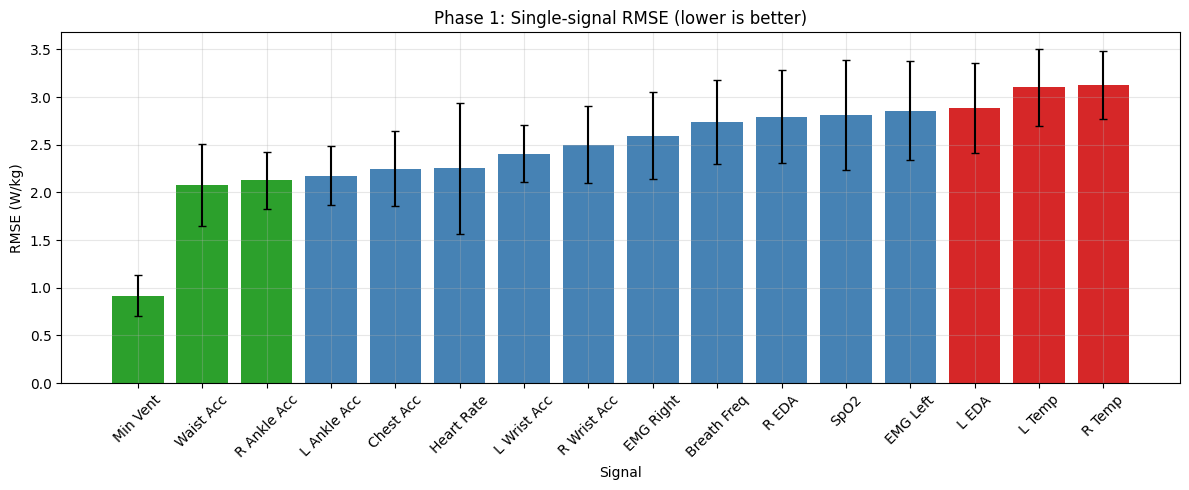


Best signal:  Min Vent  (RMSE=0.9154)
Worst signal: R Temp (RMSE=3.1218)


In [11]:
rows = []
for sig, res in single_signal_results.items():
    rows.append({
        "Signal":    SIGNAL_NAMES[sig],
        "RMSE":      res["rmse_mean"],
        "RMSE_std":  res["rmse_std"],
        "MAE":       res["mae_mean"],
        "R²":        res["r2_mean"],
    })
phase1_df = pd.DataFrame(rows).sort_values("RMSE")
print("Single-signal results (sorted by RMSE):")
print(phase1_df.to_string(index=False, float_format="%.4f"))

fig, ax = plt.subplots(figsize=(12, 5))
colors = ["#2ca02c" if i < 3 else ("#d62728" if i >= len(phase1_df)-3 else "steelblue")
          for i in range(len(phase1_df))]
ax.bar(phase1_df["Signal"], phase1_df["RMSE"], color=colors,
       yerr=phase1_df["RMSE_std"], capsize=3)
ax.set_xlabel("Signal"); ax.set_ylabel("RMSE (W/kg)")
ax.set_title("Phase 1: Single-signal RMSE (lower is better)")
ax.tick_params(axis="x", rotation=45)
ax.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

best_sig  = phase1_df.iloc[0]["Signal"]
worst_sig = phase1_df.iloc[-1]["Signal"]
print(f"\nBest signal:  {best_sig}  (RMSE={phase1_df.iloc[0]['RMSE']:.4f})")
print(f"Worst signal: {worst_sig} (RMSE={phase1_df.iloc[-1]['RMSE']:.4f})")

## 8. Phase 2 — Fusion Models

Three fusion strategies (Early, Intermediate, Late) applied to each signal group.
Same locked HP throughout. Each group × strategy combination runs full LOSO.

**Research question:** At which fusion level does multi-modal integration provide
the greatest benefit? Does the answer depend on the signal group?


In [12]:
def run_fusion_loso(group_name: str, signals: List[str],
                    fusion_type: str, hp: dict, subjects: dict) -> Dict:
    n_sig = len(signals)
    fold_metrics = []

    for test_sid in sorted(subjects.keys()):
        train_ds, val_ds, test_X, test_y, test_acts, _ = build_loso_fold(
            subjects, test_sid, signals,
            window_size=hp["window_size"], stride_train=hp["stride_train"],
            jitter_std=hp["jitter_std"], scale_range=(hp["scale_min"], hp["scale_max"]),
            aug_p=hp["aug_p"],
        )

        if fusion_type == "early":
            model = EarlyFusionModel(n_sig, hp)
        elif fusion_type == "intermediate":
            model = IntermediateFusionModel(n_sig, hp)
        elif fusion_type == "late":
            model = LateFusionModel(n_sig, hp)
        else:
            raise ValueError(f"Unknown fusion_type: {fusion_type}")

        train_model(model, train_ds, val_ds, hp["max_epochs"], hp["lr"], hp["weight_decay"],
                    hp["batch_size"], hp["patience"], DEVICE)

        model.eval()
        with torch.no_grad():
            preds = model(torch.from_numpy(test_X).to(DEVICE)).cpu().numpy().flatten()

        fold_metrics.append(activity_level_metrics(test_y, preds, test_acts))

    rmse_vals = [m["rmse"] for m in fold_metrics]
    mae_vals  = [m["mae"]  for m in fold_metrics]
    r2_vals   = [m["r2"]   for m in fold_metrics]
    return {
        "group": group_name, "fusion": fusion_type, "n_signals": n_sig,
        "rmse_mean": np.mean(rmse_vals), "rmse_std": np.std(rmse_vals),
        "mae_mean":  np.mean(mae_vals),  "mae_std":  np.std(mae_vals),
        "r2_mean":   np.mean(r2_vals),   "r2_std":   np.std(r2_vals),
        "fold_metrics": fold_metrics,
    }

if "fusion_results" not in dir():
    fusion_results = {}

FUSION_TYPES = ["early", "intermediate", "late"]

for gname, gsigs in SIGNAL_GROUPS.items():
    if gname not in fusion_results:
        fusion_results[gname] = {}
    for ftype in FUSION_TYPES:
        if ftype in fusion_results[gname]:
            print(f"{gname} | {ftype} fusion ... skipped (already done)")
            continue
        print(f"{gname} | {ftype} fusion | {len(gsigs)} signals ...")
        res = run_fusion_loso(gname, gsigs, ftype, HP, subjects)
        fusion_results[gname][ftype] = res
        print(f"  -> RMSE={res['rmse_mean']:.4f}±{res['rmse_std']:.4f} R²={res['r2_mean']:.4f}")

print("Phase 2 complete.")

G1_Local | early fusion | 8 signals ...
[2026-07-05 16:05:33,230] create_windows: dropped 770 window(s) containing NaN for signals ['Waist Acceleration', 'Chest Acceleration', 'Left Ankle Acceleration', 'right Ankle Acceleration', 'left wrist Acceleration', 'right wrist Acceleration', 'EMG_magnitude_left', 'EMG_magnitude_right']
[2026-07-05 16:05:48,135] create_windows: dropped 770 window(s) containing NaN for signals ['Waist Acceleration', 'Chest Acceleration', 'Left Ankle Acceleration', 'right Ankle Acceleration', 'left wrist Acceleration', 'right wrist Acceleration', 'EMG_magnitude_left', 'EMG_magnitude_right']
[2026-07-05 16:05:57,921] create_windows: dropped 770 window(s) containing NaN for signals ['Waist Acceleration', 'Chest Acceleration', 'Left Ankle Acceleration', 'right Ankle Acceleration', 'left wrist Acceleration', 'right wrist Acceleration', 'EMG_magnitude_left', 'EMG_magnitude_right']
[2026-07-05 16:06:12,383] create_windows: dropped 770 window(s) containing NaN for sign

           Group       Fusion  N_signals   RMSE  RMSE_std    MAE     R²
        G1_Local        early          8 1.8138    0.5247 1.4368 0.5453
        G1_Local intermediate          8 1.7297    0.5143 1.4260 0.5757
        G1_Local         late          8 1.7228    0.5934 1.4156 0.5667
       G2_Global        early          8 1.5083    0.5876 1.1900 0.6995
       G2_Global intermediate          8 0.9866    0.4035 0.8214 0.8638
       G2_Global         late          8 1.0028    0.4257 0.7981 0.8565
     G3_Hexoskin        early          4 0.9731    0.2303 0.7895 0.8798
     G3_Hexoskin intermediate          4 0.9235    0.2978 0.7525 0.8967
     G3_Hexoskin         late          4 0.9714    0.3157 0.7953 0.8843
G4_Physiological        early          4 1.0465    0.2445 0.8415 0.8665
G4_Physiological intermediate          4 0.9972    0.3499 0.8543 0.8754
G4_Physiological         late          4 1.0124    0.4821 0.8396 0.8654
       G5_Motion        early          6 1.7728    0.2717 1.3791

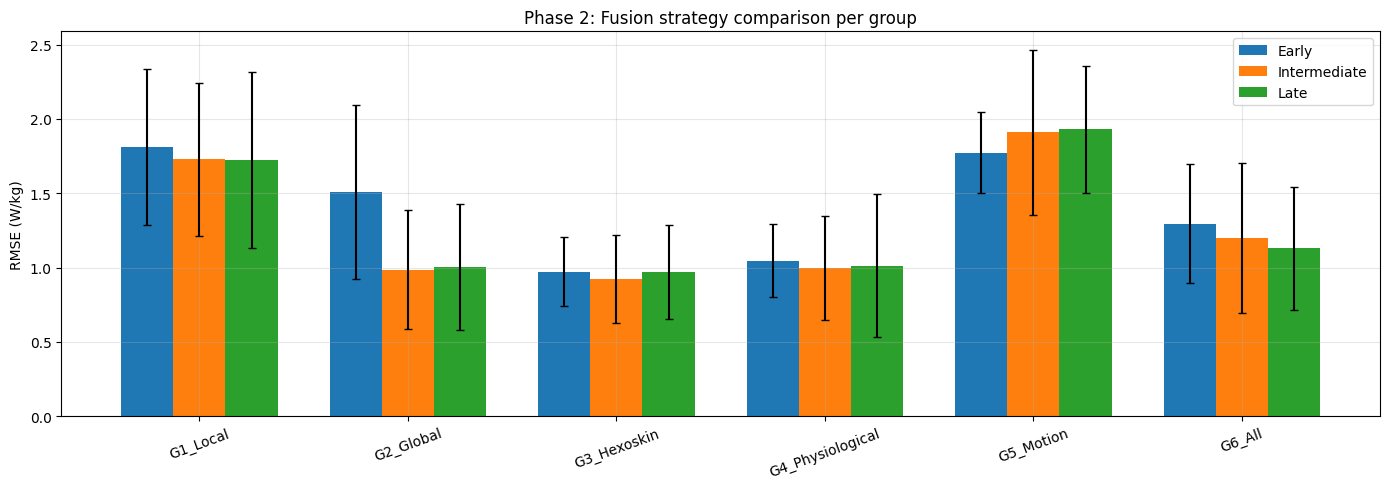

In [13]:
fusion_rows = []
for gname, ftypes in fusion_results.items():
    for ftype, res in ftypes.items():
        fusion_rows.append({
            "Group": gname, "Fusion": ftype,
            "N_signals": res["n_signals"],
            "RMSE": res["rmse_mean"], "RMSE_std": res["rmse_std"],
            "MAE":  res["mae_mean"],
            "R²":   res["r2_mean"],
        })
fusion_df = pd.DataFrame(fusion_rows).sort_values(["Group","Fusion"])
print(fusion_df.to_string(index=False, float_format="%.4f"))

groups = list(SIGNAL_GROUPS.keys())
x = np.arange(len(groups))
width = 0.25
colors_f = {"early": "#1f77b4", "intermediate": "#ff7f0e", "late": "#2ca02c"}

fig, ax = plt.subplots(figsize=(14, 5))
for i, ftype in enumerate(FUSION_TYPES):
    rmse_vals = [fusion_results[g][ftype]["rmse_mean"] for g in groups]
    rmse_stds = [fusion_results[g][ftype]["rmse_std"]  for g in groups]
    ax.bar(x + (i - 1)*width, rmse_vals, width, label=ftype.capitalize(),
           color=colors_f[ftype], yerr=rmse_stds, capsize=3)

ax.set_xticks(x); ax.set_xticklabels(groups, rotation=20)
ax.set_ylabel("RMSE (W/kg)"); ax.set_title("Phase 2: Fusion strategy comparison per group")
ax.legend(); ax.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

## 9. Regularization Analysis

Demonstrates the overfitting problem on this small dataset (10 subjects, LOSO)
and shows the effect of regularization. Uses Heart Rate (single-signal) with two
configurations:
- **No regularization:** dropout=0, weight_decay=0, augmentation disabled (jitter_std=0, aug_p=0),
  early stopping effectively disabled (patience=max_epochs=80).
- **With regularization:** the locked HP, which includes dropout, weight decay,
  early stopping, and data augmentation together.

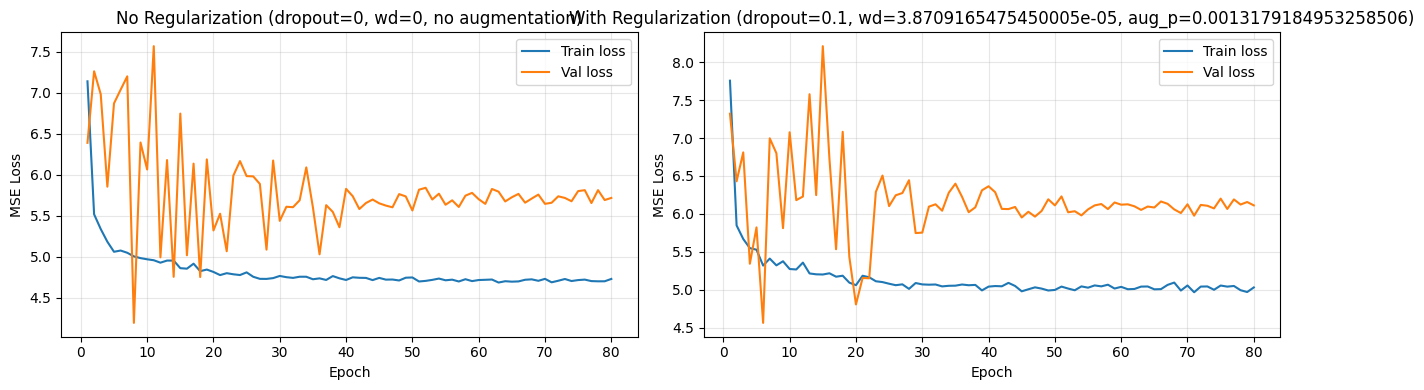

Without regularization — train/val gap at final epoch: 0.9881
With regularization    — train/val gap at final epoch: 1.0824


In [14]:
def train_with_history(model, train_ds, val_ds, hp, device):
    _, history = train_model(
        model, train_ds, val_ds, hp["max_epochs"], hp["lr"], hp["weight_decay"],
        hp["batch_size"], hp["patience"], device, verbose=True
    )
    return history

train_ds_hr, val_ds_hr, _, _, _, _ = build_loso_fold(
    subjects, test_sid=1, signals=["Heart Rate"],
    window_size=HP["window_size"], stride_train=HP["stride_train"],
    jitter_std=HP["jitter_std"], scale_range=(HP["scale_min"], HP["scale_max"]),
    aug_p=HP["aug_p"],
)
hp_reg = {**HP, "max_epochs": 80, "patience": 80}
model_reg = SingleSignalModel(hp_reg)
history_reg = train_with_history(model_reg, train_ds_hr, val_ds_hr, hp_reg, DEVICE)

train_ds_hr_noreg, val_ds_hr_noreg, _, _, _, _ = build_loso_fold(
    subjects, test_sid=1, signals=["Heart Rate"],
    window_size=HP["window_size"], stride_train=HP["stride_train"],
    jitter_std=0.0, scale_range=(1.0, 1.0), aug_p=0.0,
)
hp_noreg = {**HP, "dropout": 0.0, "weight_decay": 0.0,
            "jitter_std": 0.0, "aug_p": 0.0,
            "max_epochs": 80, "patience": 80}
model_noreg = SingleSignalModel(hp_noreg)
history_noreg = train_with_history(model_noreg, train_ds_hr_noreg, val_ds_hr_noreg, hp_noreg, DEVICE)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, hist, title in zip(axes,
                             [history_noreg, history_reg],
                             ["No Regularization (dropout=0, wd=0, no augmentation)",
                              f"With Regularization (dropout={HP['dropout']}, wd={HP['weight_decay']}, "
                              f"aug_p={HP['aug_p']})"]):
    epochs = range(1, len(hist["train"]) + 1)
    ax.plot(epochs, hist["train"], label="Train loss")
    ax.plot(epochs, hist["val"],   label="Val loss")
    ax.set_xlabel("Epoch"); ax.set_ylabel("MSE Loss")
    ax.set_title(title); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

gap_noreg = np.array(history_noreg["train"][-1]) - np.array(history_noreg["val"][-1])
gap_reg   = np.array(history_reg["train"][-1])   - np.array(history_reg["val"][-1])
print(f"Without regularization \u2014 train/val gap at final epoch: {abs(gap_noreg):.4f}")
print(f"With regularization    \u2014 train/val gap at final epoch: {abs(gap_reg):.4f}")

## 10. Results & Visualizations

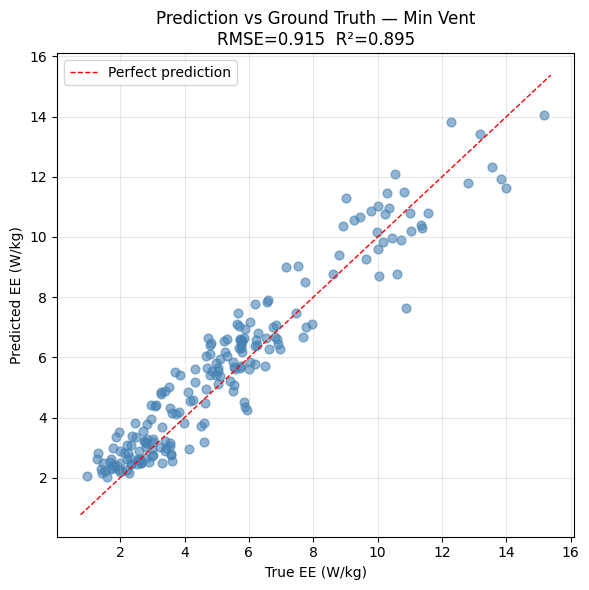

In [15]:
best_signal_name = phase1_df.iloc[0]["Signal"]
best_signal_col  = [s for s in ALL_SIGNALS if SIGNAL_NAMES[s] == best_signal_name][0]
best_res = single_signal_results[best_signal_col]

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(best_res["y_true"], best_res["y_pred"], alpha=0.6, s=40, color="steelblue")
lims = [min(best_res["y_true"].min(), best_res["y_pred"].min()) - 0.2,
        max(best_res["y_true"].max(), best_res["y_pred"].max()) + 0.2]
ax.plot(lims, lims, "r--", linewidth=1, label="Perfect prediction")
ax.set_xlabel("True EE (W/kg)"); ax.set_ylabel("Predicted EE (W/kg)")
ax.set_title(f"Prediction vs Ground Truth — {best_signal_name}\n"
             f"RMSE={best_res['rmse_mean']:.3f}  R²={best_res['r2_mean']:.3f}")
ax.legend(); ax.grid(True, alpha=0.3); plt.tight_layout(); plt.show()


In [16]:
print("PHASE 1 SUMMARY")
print(phase1_df[["Signal","RMSE","MAE","R²"]].to_string(index=False, float_format="%.4f"))

print("PHASE 2 SUMMARY")
print(fusion_df[["Group","Fusion","N_signals","RMSE","MAE","R²"]].to_string(
    index=False, float_format="%.4f"))

print("KEY FINDINGS")

best_fusion = fusion_df.sort_values("RMSE").iloc[0]
print(f"Best overall: {best_fusion['Group']} | {best_fusion['Fusion']} fusion "
      f"| RMSE={best_fusion['RMSE']:.4f}")
print(f"Best single signal: {phase1_df.iloc[0]['Signal']} "
      f"| RMSE={phase1_df.iloc[0]['RMSE']:.4f}")
for gname in groups:
    best_f = min(FUSION_TYPES, key=lambda f: fusion_results[gname][f]["rmse_mean"])
    best_rmse = fusion_results[gname][best_f]["rmse_mean"]
    print(f"  {gname:20s}: best fusion = {best_f:14s} | RMSE={best_rmse:.4f}")

PHASE 1 SUMMARY
     Signal   RMSE    MAE      R²
   Min Vent 0.9154 0.7666  0.8949
  Waist Acc 2.0796 1.7135  0.4927
R Ankle Acc 2.1255 1.7017  0.4629
L Ankle Acc 2.1763 1.7463  0.4345
  Chest Acc 2.2501 1.8317  0.3965
 Heart Rate 2.2522 1.8358  0.3432
L Wrist Acc 2.4043 1.9764  0.2923
R Wrist Acc 2.4986 2.0430  0.2147
  EMG Right 2.5967 2.0976  0.1881
Breath Freq 2.7377 2.2277  0.0220
      R EDA 2.7935 2.1285  0.0702
       SpO2 2.8105 2.2373  0.0774
   EMG Left 2.8589 2.2841  0.0083
      L EDA 2.8862 2.2658  0.0395
     L Temp 3.1005 2.4275 -0.1214
     R Temp 3.1218 2.4683 -0.1796
PHASE 2 SUMMARY
           Group       Fusion  N_signals   RMSE    MAE     R²
        G1_Local        early          8 1.8138 1.4368 0.5453
        G1_Local intermediate          8 1.7297 1.4260 0.5757
        G1_Local         late          8 1.7228 1.4156 0.5667
       G2_Global        early          8 1.5083 1.1900 0.6995
       G2_Global intermediate          8 0.9866 0.8214 0.8638
       G2_Global  

In [17]:
import pickle, json
from pathlib import Path
import pandas as pd

OUTPUT_DIR = Path("/kaggle/working")
OUTPUT_DIR.mkdir(exist_ok=True)

payload = {
    "single_signal_results": single_signal_results,
    "fusion_results": fusion_results,
    "HP": HP,
}
with open(OUTPUT_DIR / "results_full.pkl", "wb") as f:
    pickle.dump(payload, f)

with open(OUTPUT_DIR / "locked_hyperparameters.json", "w") as f:
    json.dump(HP, f, indent=2)

rows = []
for sig, r in single_signal_results.items():
    rows.append({
        "signal": SIGNAL_NAMES.get(sig, sig),
        "rmse_mean": r["rmse_mean"], "rmse_std": r["rmse_std"],
        "mae_mean": r["mae_mean"], "mae_std": r["mae_std"],
        "r2_mean": r["r2_mean"], "r2_std": r["r2_std"],
    })
single_signal_df = pd.DataFrame(rows).sort_values("rmse_mean").reset_index(drop=True)
single_signal_df.to_csv(OUTPUT_DIR / "single_signal_ranking.csv", index=False)

rows = []
for gname, ftypes in fusion_results.items():
    for ftype, r in ftypes.items():
        rows.append({
            "group": gname, "fusion": ftype, "n_signals": r["n_signals"],
            "rmse_mean": r["rmse_mean"], "rmse_std": r["rmse_std"],
            "mae_mean": r["mae_mean"], "mae_std": r["mae_std"],
            "r2_mean": r["r2_mean"], "r2_std": r["r2_std"],
        })
fusion_df = pd.DataFrame(rows).sort_values(["group", "fusion"]).reset_index(drop=True)
fusion_df.to_csv(OUTPUT_DIR / "fusion_comparison.csv", index=False)

print("Saved to /kaggle/working:")
for f in sorted(OUTPUT_DIR.glob("*")):
    if f.name in ("results_full.pkl", "locked_hyperparameters.json",
                  "single_signal_ranking.csv", "fusion_comparison.csv"):
        print(" -", f.name, f"({f.stat().st_size/1024:.1f} KB)")

single_signal_df

Saved to /kaggle/working:
 - fusion_comparison.csv (2.5 KB)
 - locked_hyperparameters.json (0.4 KB)
 - results_full.pkl (120.0 KB)
 - single_signal_ranking.csv (2.0 KB)


,signal,rmse_mean,rmse_std,mae_mean,mae_std,r2_mean,r2_std
0,Min Vent,0.915412,0.214589,0.766638,0.234014,0.894874,0.049646
1,Waist Acc,2.079568,0.431706,1.713500,0.327413,0.492656,0.146863
2,R Ankle Acc,2.125509,0.295011,1.701666,0.226340,0.462863,0.143190
3,L Ankle Acc,2.176321,0.309687,1.746332,0.274434,0.434479,0.162317
4,Chest Acc,2.250092,0.392681,1.831651,0.253441,0.396465,0.187537
5,Heart Rate,2.252190,0.683444,1.835772,0.523670,0.343222,0.458309
6,L Wrist Acc,2.404320,0.297555,1.976426,0.209522,0.292262,0.260416
7,R Wrist Acc,2.498635,0.402889,2.043050,0.288806,0.214677,0.292712
8,EMG Right,2.596654,0.452047,2.097570,0.467692,0.188119,0.346427
9,Breath Freq,2.737696,0.439839,2.227707,0.418457,0.022032,0.681113
